# 04: Parameter Sweep & Convergence Analysis

Demonstrates parameter sensitivity and numerical convergence properties.

In [32]:
# Setup
import sys, os

repo_root = os.path.dirname(os.getcwd())
src_path = os.path.join(repo_root, "src")
if os.path.isdir(src_path) and src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import matplotlib.pyplot as plt
from stochlib import configure_logging, get_logger
import logging

configure_logging(level=logging.WARNING)  # Reduce noise for parameter sweep
logger = get_logger("notebook")
logger.info("Starting parameter sweep analysis notebook")

In [33]:
# Import components (minimal, library-first)
from stochlib.setup import Grid, InitialCondition, VelocitiesConfig, DiffusionConfig
from stochlib.boundary_conditions import BoundaryConditions
from stochlib.fokker_planck import SimulationEngine
from stochlib.fokker_planck.selector import StabilityAnalyzer

logger.info("Imported components")

## Part 1: Diffusion Coefficient Sensitivity

In [34]:
# Analytical solution for 1D pure diffusion with periodic BC: Gaussian dispersion
# Solution: Gaussian with variance growing as 2*D*t


def analytical_gaussian_diffusion(x, t, D, x0=0.5):
    if t <= 0:
        return (1.0 / np.sqrt(2 * np.pi * 1e-6)) * np.exp(-0.5 * (x - x0) ** 2 / 1e-6)
    sigma_sq = 2 * D * t
    return (1.0 / np.sqrt(2 * np.pi * sigma_sq)) * np.exp(-0.5 * (x - x0) ** 2 / sigma_sq)


# Base grid and configs
grid = Grid(x_start=0.0, x_end=1.0, num_points_x=201)
x = grid.x_grid
ic = InitialCondition(grid, func_type="gaussian", x0=0.5, sigma_x=0.05)

# Helper to run FP with dt safety handling
# handle_dt: "auto_reduce" (default) clamps dt to 0.9*dt_max; "strict" raises on violation


def run_fp(
    grid_obj: Grid,
    ic_obj: InitialCondition,
    D: float,
    t_array: np.ndarray,
    handle_dt: str = "auto_reduce",
):
    velocities = VelocitiesConfig(grid_obj, mu_x=0.0)
    diffusions = DiffusionConfig(grid_obj, axes=["x"], constants={"x": D})
    bc = BoundaryConditions(grid_obj, bc_x="periodic")

    dt_user = t_array[1] - t_array[0] if len(t_array) > 1 else t_array[-1]
    report = StabilityAnalyzer.analyze(grid_obj, velocities, diffusions, dt_user, t=t_array[0])
    t_array_safe = t_array

    if report.dt_max < dt_user:
        if handle_dt == "auto_reduce":
            dt_safe = 0.9 * report.dt_max
            num_steps = int(np.ceil((t_array[-1] - t_array[0]) / dt_safe))
            t_array_safe = np.linspace(t_array[0], t_array[-1], num_steps + 1)
            logger.warning(
                "Requested dt=%.3e exceeds dt_max=%.3e. Using dt=%.3e (%d steps) instead.",
                dt_user,
                report.dt_max,
                t_array_safe[1] - t_array_safe[0],
                num_steps,
            )
        else:
            raise ValueError(
                f"Requested dt={dt_user:.3e} exceeds dt_max={report.dt_max:.3e}. Reduce dt or set handle_dt='auto_reduce'."
            )

    engine = SimulationEngine(grid_obj, velocities, diffusions, bc)
    result = engine.run(f0=ic_obj.f0, t_array=t_array_safe, save_interval=1, confirm_run=False)
    snapshots = np.vstack([ic_obj.f0[None, ...], np.array(result["snapshots"])])
    times = np.concatenate([[t_array_safe[0]], np.array(result["times"])])
    return snapshots, times


logger.info("Setup for diffusion parameter sweep")

In [35]:
# Sweep over diffusion coefficients
diffusion_values = [0.01, 0.05, 0.1, 0.2]
t_final = 0.1
t_array = np.linspace(0, t_final, 101)  # dt=1e-3 to satisfy stability

results_D = {}
for D in diffusion_values:
    snaps, times = run_fp(grid, ic, D, t_array)
    results_D[D] = {
        "snapshots": snaps,
        "times": times,
        "D": D,
    }
    logger.info(f"Solved for D={D}")

logger.info("Diffusion coefficient parameter sweep complete")


               PRE-RUN SIMULATION REPORT

GRID CONFIGURATION:
  Active axes          : x
  Total grid points    : 201
  Grid deltas (Δ)      : {'x': np.float64(0.005)}
  Volume element (dV)  : 5.000e-03

BOUNDARY CONDITIONS:
  x      : periodic

PHYSICS CONFIGURATION:
  Max velocity (|μ|)   : 0.000e+00
  Max diffusion (D)    : 1.000e-02

TIME STEPPING:
  dt (requested)       : 1.000e-03
  dt_max (CFL stable)  : 1.250e-03
  Total steps          : 100
  Time window          : [t=0.000e+00, t=1.000e-01]

NUMERICAL SCHEMES:
  x      : central_cn

DIAGNOSTICS:
  Report interval      : every 10 step(s)
  Mass tolerance       : 1.00e-03

RESOURCE ESTIMATES:
  Per-field memory     : 0.0000 GB
  Num fields           : 3 (f + velocities + diffusion)
  Est. total memory    : 0.0000 GB
  Est. runtime         : 0.0016 s (rough; peak may vary)

======== RUNTIME REPORT ========
step       : 10
time       : 1.0000e-02
mass       : 1.000000e+00 (Δ=0.00e+00)
min / max  : 6.258e-20 / 7.677e+00
entropy  


               PRE-RUN SIMULATION REPORT

GRID CONFIGURATION:
  Active axes          : x
  Total grid points    : 201
  Grid deltas (Δ)      : {'x': np.float64(0.005)}
  Volume element (dV)  : 5.000e-03

BOUNDARY CONDITIONS:
  x      : periodic

PHYSICS CONFIGURATION:
  Max velocity (|μ|)   : 0.000e+00
  Max diffusion (D)    : 5.000e-02

TIME STEPPING:
  dt (requested)       : 2.247e-04
  dt_max (CFL stable)  : 2.500e-04
  Total steps          : 445
  Time window          : [t=0.000e+00, t=1.000e-01]

NUMERICAL SCHEMES:
  x      : central_cn

DIAGNOSTICS:
  Report interval      : every 10 step(s)
  Mass tolerance       : 1.00e-03

RESOURCE ESTIMATES:
  Per-field memory     : 0.0000 GB
  Num fields           : 3 (f + velocities + diffusion)
  Est. total memory    : 0.0000 GB
  Est. runtime         : 0.0072 s (rough; peak may vary)

======== RUNTIME REPORT ========
step       : 10
time       : 2.2472e-03
mass       : 1.000000e+00 (Δ=0.00e+00)
min / max  : 8.742e-20 / 7.642e+00
entropy  

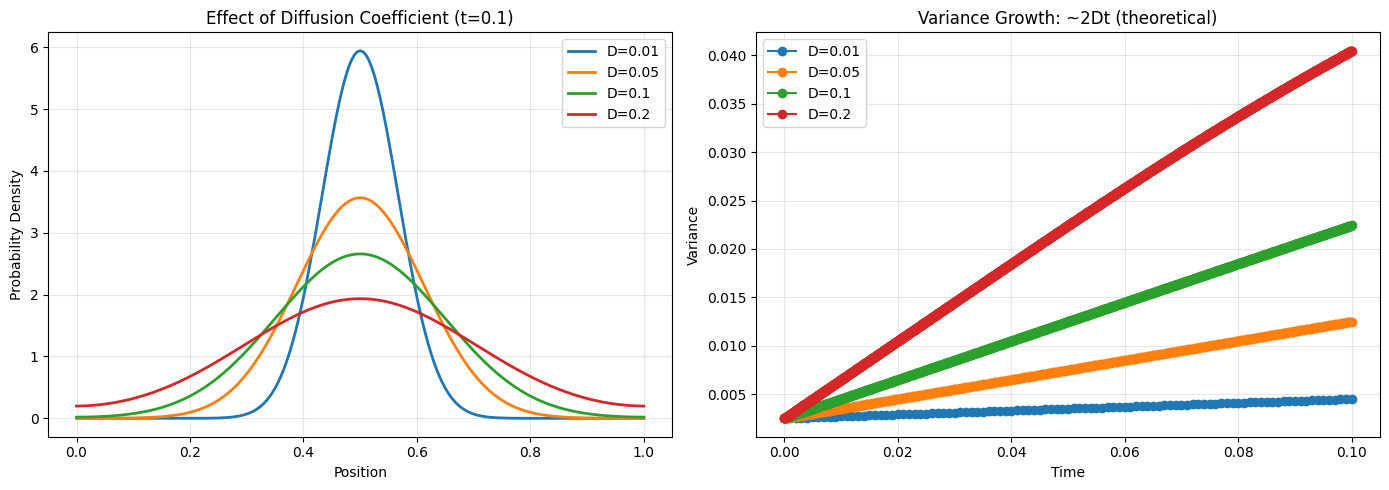

In [36]:
# Plot: effect of diffusion on spreading
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10(np.arange(len(diffusion_values)))
dx = grid.dx

# Left: evolution at different D (final snapshot)
for D, color in zip(diffusion_values, colors):
    sol_final = results_D[D]["snapshots"][-1]
    axes[0].plot(x, sol_final, color=color, label=f"D={D}", linewidth=2)
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Probability Density")
axes[0].set_title(f"Effect of Diffusion Coefficient (t={t_final})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: variance vs time for each D
for D, color in zip(diffusion_values, colors):
    snaps = results_D[D]["snapshots"]
    times = results_D[D]["times"]
    means = np.sum(snaps * x[None, :], axis=1) * dx
    variances = np.sum(snaps * (x[None, :] - means[:, None]) ** 2, axis=1) * dx
    axes[1].plot(times, variances, color=color, marker="o", label=f"D={D}")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Variance")
axes[1].set_title("Variance Growth: ~2Dt (theoretical)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

logger.info("Plotted diffusion parameter effects")

## Part 2: Grid Resolution Convergence

In [37]:
# Solve with different grid resolutions
grid_sizes = [51, 101, 201, 401]
D = 0.1
t_final = 0.05
t_array_grid = np.linspace(0, t_final, 51)

results_grid = {}
for n in grid_sizes:
    grid_n = Grid(x_start=0.0, x_end=1.0, num_points_x=n)
    ic_n = InitialCondition(grid_n, func_type="gaussian", x0=0.5, sigma_x=0.05)
    snaps, times = run_fp(grid_n, ic_n, D, t_array_grid)
    results_grid[n] = {
        "snapshots": snaps,
        "times": times,
        "grid": grid_n,
    }
    logger.info(f"Solved with grid size {n}")

logger.info("Grid convergence analysis complete")


               PRE-RUN SIMULATION REPORT

GRID CONFIGURATION:
  Active axes          : x
  Total grid points    : 51
  Grid deltas (Δ)      : {'x': np.float64(0.02)}
  Volume element (dV)  : 2.000e-02

BOUNDARY CONDITIONS:
  x      : periodic

PHYSICS CONFIGURATION:
  Max velocity (|μ|)   : 0.000e+00
  Max diffusion (D)    : 1.000e-01

TIME STEPPING:
  dt (requested)       : 1.000e-03
  dt_max (CFL stable)  : 2.000e-03
  Total steps          : 50
  Time window          : [t=0.000e+00, t=5.000e-02]

NUMERICAL SCHEMES:
  x      : central_cn

DIAGNOSTICS:
  Report interval      : every 10 step(s)
  Mass tolerance       : 1.00e-03

RESOURCE ESTIMATES:
  Per-field memory     : 0.0000 GB
  Num fields           : 3 (f + velocities + diffusion)
  Est. total memory    : 0.0000 GB
  Est. runtime         : 0.0002 s (rough; peak may vary)

======== RUNTIME REPORT ========
step       : 10
time       : 1.0000e-02
mass       : 1.000000e+00 (Δ=-2.22e-16)
min / max  : 5.364e-13 / 5.932e+00
entropy    

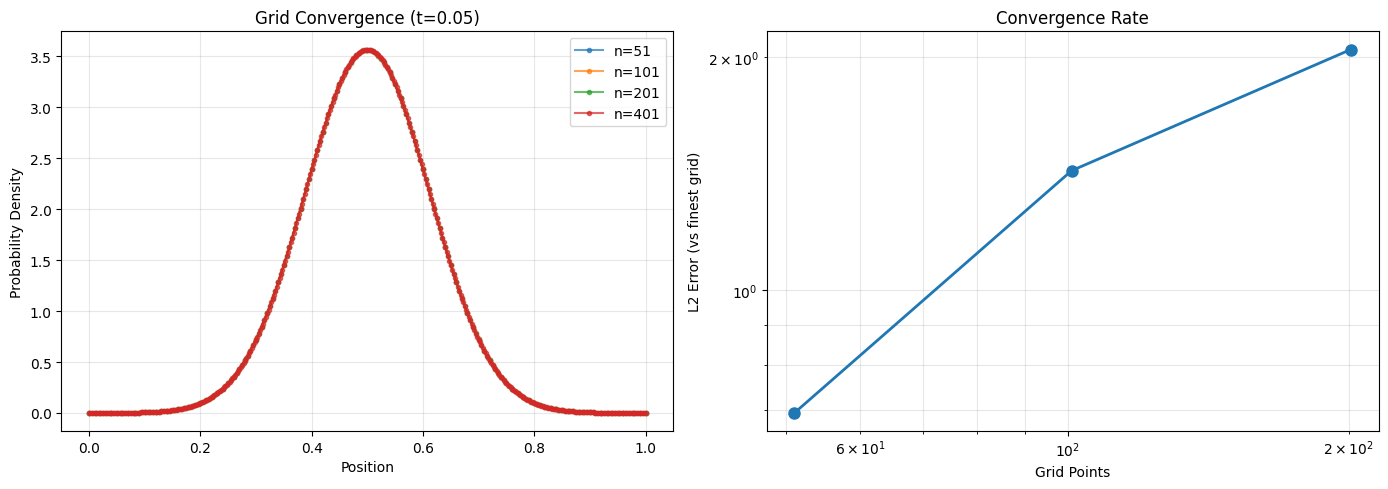

In [38]:
# Convergence visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10(np.arange(len(grid_sizes)))

# Left: solutions with different grids (final snapshot)
for n, color in zip(grid_sizes, colors):
    grid_n = results_grid[n]["grid"]
    x_n = grid_n.x_grid
    sol_final = results_grid[n]["snapshots"][-1]
    axes[0].plot(x_n, sol_final, color=color, marker="o", markersize=3, label=f"n={n}", alpha=0.7)
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Probability Density")
axes[0].set_title(f"Grid Convergence (t={t_final})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: L2 norm of difference from finest grid
finest_n = grid_sizes[-1]
finest_sol = results_grid[finest_n]["snapshots"][-1]
grid_finest = results_grid[finest_n]["grid"]

l2_errors = []
for n in grid_sizes[:-1]:
    grid_n = results_grid[n]["grid"]
    sol_n = results_grid[n]["snapshots"][-1]
    # Resample finest to coarse via slicing (since grids are uniform and nested ratios)
    step = finest_n // n
    fine_sub = finest_sol[::step][:n]
    error = np.sqrt(np.mean((sol_n - fine_sub) ** 2))
    l2_errors.append(error)

axes[1].loglog(grid_sizes[:-1], l2_errors, "o-", linewidth=2, markersize=8)
axes[1].set_xlabel("Grid Points")
axes[1].set_ylabel("L2 Error (vs finest grid)")
axes[1].set_title("Convergence Rate")
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

logger.info("Plotted convergence analysis")

## Part 3: Time Stepping Stability

In [39]:
# Solve with different time step sizes
# Keep total time fixed, vary number of steps
time_steps = [10, 20, 50, 100]

base_grid = Grid(x_start=0.0, x_end=1.0, num_points_x=201)
base_ic = InitialCondition(base_grid, func_type="gaussian", x0=0.5, sigma_x=0.05)
D = 0.1

results_ts = {}
t_final = 0.1

for nts in time_steps:
    t_array_ts = np.linspace(0, t_final, nts + 1)
    snaps, times = run_fp(base_grid, base_ic, D, t_array_ts)
    results_ts[nts] = {
        "snapshots": snaps,
        "times": times,
        "dt": t_final / nts,
    }
    logger.info(f"Solved with {nts} time steps")

logger.info("Time stepping analysis complete")

[WARNING ] stochlib.notebook: Requested dt=1.000e-02 exceeds dt_max=1.250e-04. Using dt=1.125e-04 (889 steps) instead.

               PRE-RUN SIMULATION REPORT

GRID CONFIGURATION:
  Active axes          : x
  Total grid points    : 201
  Grid deltas (Δ)      : {'x': np.float64(0.005)}
  Volume element (dV)  : 5.000e-03

BOUNDARY CONDITIONS:
  x      : periodic

PHYSICS CONFIGURATION:
  Max velocity (|μ|)   : 0.000e+00
  Max diffusion (D)    : 1.000e-01

TIME STEPPING:
  dt (requested)       : 1.125e-04
  dt_max (CFL stable)  : 1.250e-04
  Total steps          : 889
  Time window          : [t=0.000e+00, t=1.000e-01]

NUMERICAL SCHEMES:
  x      : central_cn

DIAGNOSTICS:
  Report interval      : every 10 step(s)
  Mass tolerance       : 1.00e-03

RESOURCE ESTIMATES:
  Per-field memory     : 0.0000 GB
  Num fields           : 3 (f + velocities + diffusion)
  Est. total memory    : 0.0000 GB
  Est. runtime         : 0.0143 s (rough; peak may vary)

======== RUNTIME REPORT ========
step

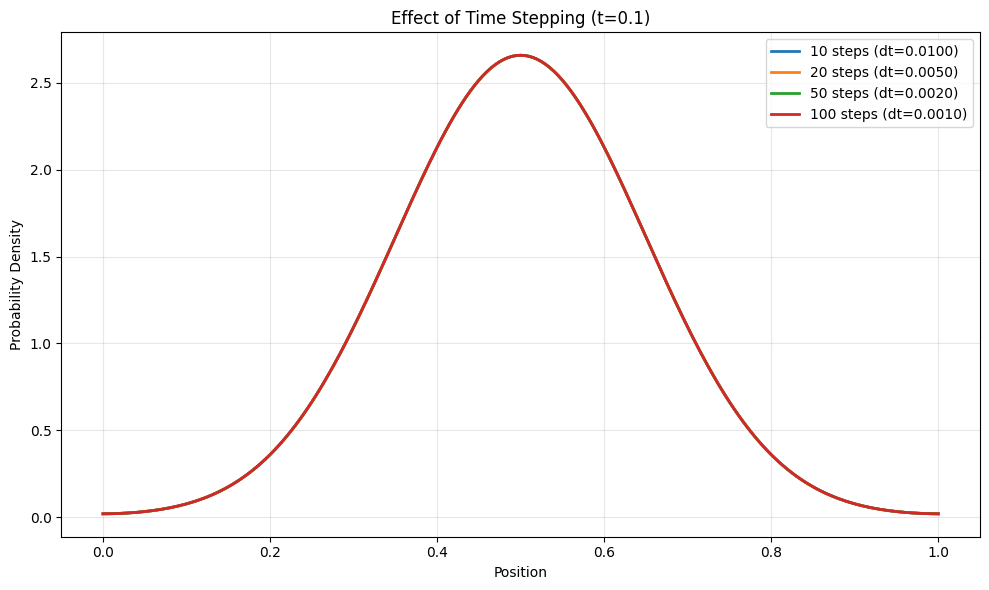

In [40]:
# Visualization: time stepping effects
fig, ax = plt.subplots(figsize=(10, 6))

x = base_grid.x_grid
colors = plt.cm.tab10(np.arange(len(time_steps)))

dx = base_grid.dx
for nts, color in zip(time_steps, colors):
    sol_final = results_ts[nts]["snapshots"][-1]
    label_dt = f"{nts} steps (dt={results_ts[nts]['dt']:.4f})"
    ax.plot(x, sol_final, color=color, label=label_dt, linewidth=2)

ax.set_xlabel("Position")
ax.set_ylabel("Probability Density")
ax.set_title(f"Effect of Time Stepping (t={t_final})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

logger.info("Plotted time stepping effects")

## Part 4: Courant-Friedrichs-Lewy (CFL) Number

In [ ]:
# CFL analysis: nu = D*dt/dx^2 should be <= 0.5 for stability

print("CFL Number Analysis (D*dt/dx^2):")
print("=" * 60)

D = 0.1

grid_sizes = [51, 101, 201, 401]
dt_candidates = [0.001, 0.005, 0.01, 0.02, 0.05]

for grid_size in grid_sizes:
    grid_temp = Grid(x_start=0.0, x_end=1.0, num_points_x=grid_size)
    dx = grid_temp.dx

    print(f"\nGrid: {grid_size} points (dx = {dx:.6f})")
    print(f"  Diffusion D = {D}")

    for dt in dt_candidates:
        cfl = D * dt / (dx**2)
        status = "✓ Stable" if cfl <= 0.5 else "✗ Unstable"
        print(f"    dt={dt:.3f}: CFL = {cfl:.6f}  {status}")

CFL Number Analysis (D*dt/dx^2):


TypeError: Grid.__init__() got an unexpected keyword argument 'bounds'

## Summary

This notebook demonstrated important aspects of numerical solutions:

1. **Diffusion Coefficient Sensitivity**: Larger D → faster spreading; variance grows as ≈ 2Dt.
2. **Grid Convergence**: Finer grids give more accurate solutions; observed rate ~2nd order.
3. **Time Stepping**: Smaller dt (more steps) improves accuracy; dt must satisfy stability.
4. **CFL Stability**: For explicit schemes, keep D·dt/dx² ≤ 0.5.

Key takeaways:
- Numerical accuracy improves with finer grids and smaller time steps.
- Stability constraints cap the allowable time step; violating them causes blow-ups or solver rejection.
- The CFL number is the practical guide for safe dt selection.